In [1]:
import tensorflow as tf

#  this simply helps us skip wrnings in out output
import warnings 
warnings.filterwarnings("ignore")


I0000 00:00:1790875339.427303   34229 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790875339.536070   34229 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790875342.492692   34229 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
mnist = tf.keras.datasets.mnist

In [3]:
mnist

<module 'keras.datasets.mnist' from '/home/josephridge/Documents/@software-engineering/@datascience/@emobilis/@dataScience-MAY/deep-learning101/env/lib/python3.13/site-packages/keras/datasets/mnist/__init__.py'>

In [4]:
mnist.load_data()

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [5]:
(x_train, y_train),(x_test, y_test) = mnist.load_data()

In [6]:
x_train[7]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  38,  43,
        105, 255, 253, 253, 253, 253, 253, 174,   6,   0,   0,   0,   0,
          0,   0],
       [  

In [7]:
y_test

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [8]:
x_train, x_test = x_train / 255.0, x_test / 255.0  # they allow inseatd of the pizels to transition from 0 -255 but to 0-1 this helps in convergence

In [9]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)), # this goes ahead and :flattens the grid into 784 numbers

  # This is your first hidden layer n 128 neurons
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),# 20% of your data is left out to lower the chance pof overfittinhs

  # This is your first hidden layer n 64 neurons
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dropout(0.2),# 20% of your data is left out to lower the chance pof overfittinh
  
  tf.keras.layers.Dense(10, activation='softmax')
])

E0000 00:00:1790793002.691629   42928 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
model.compile(
    optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

In [11]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.8992 - loss: 0.3366
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9520 - loss: 0.1626
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9612 - loss: 0.1274
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9668 - loss: 0.1075
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9707 - loss: 0.0942


In [12]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9757 - loss: 0.0832


[0.08322558552026749, 0.9757000207901001]

# 1 hiddent layer

In [ ]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)), # this goes ahead and :flattens the grid into 784 numbers

  # This is your first hidden layer n 128 neurons
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),# 20% of your data is left out to lower the chance pof overfittinhs

  # # This is your first hidden layer n 64 neurons
  # tf.keras.layers.Dense(64, activation='relu'),
  # tf.keras.layers.Dropout(0.2),# 20% of your data is left out to lower the chance pof overfittinh
  
  tf.keras.layers.Dense(10, activation='softmax')
])

In [19]:
model.compile(
    optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

In [20]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9126 - loss: 0.3007
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9567 - loss: 0.1454
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9669 - loss: 0.1078
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9725 - loss: 0.0898
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9763 - loss: 0.0752


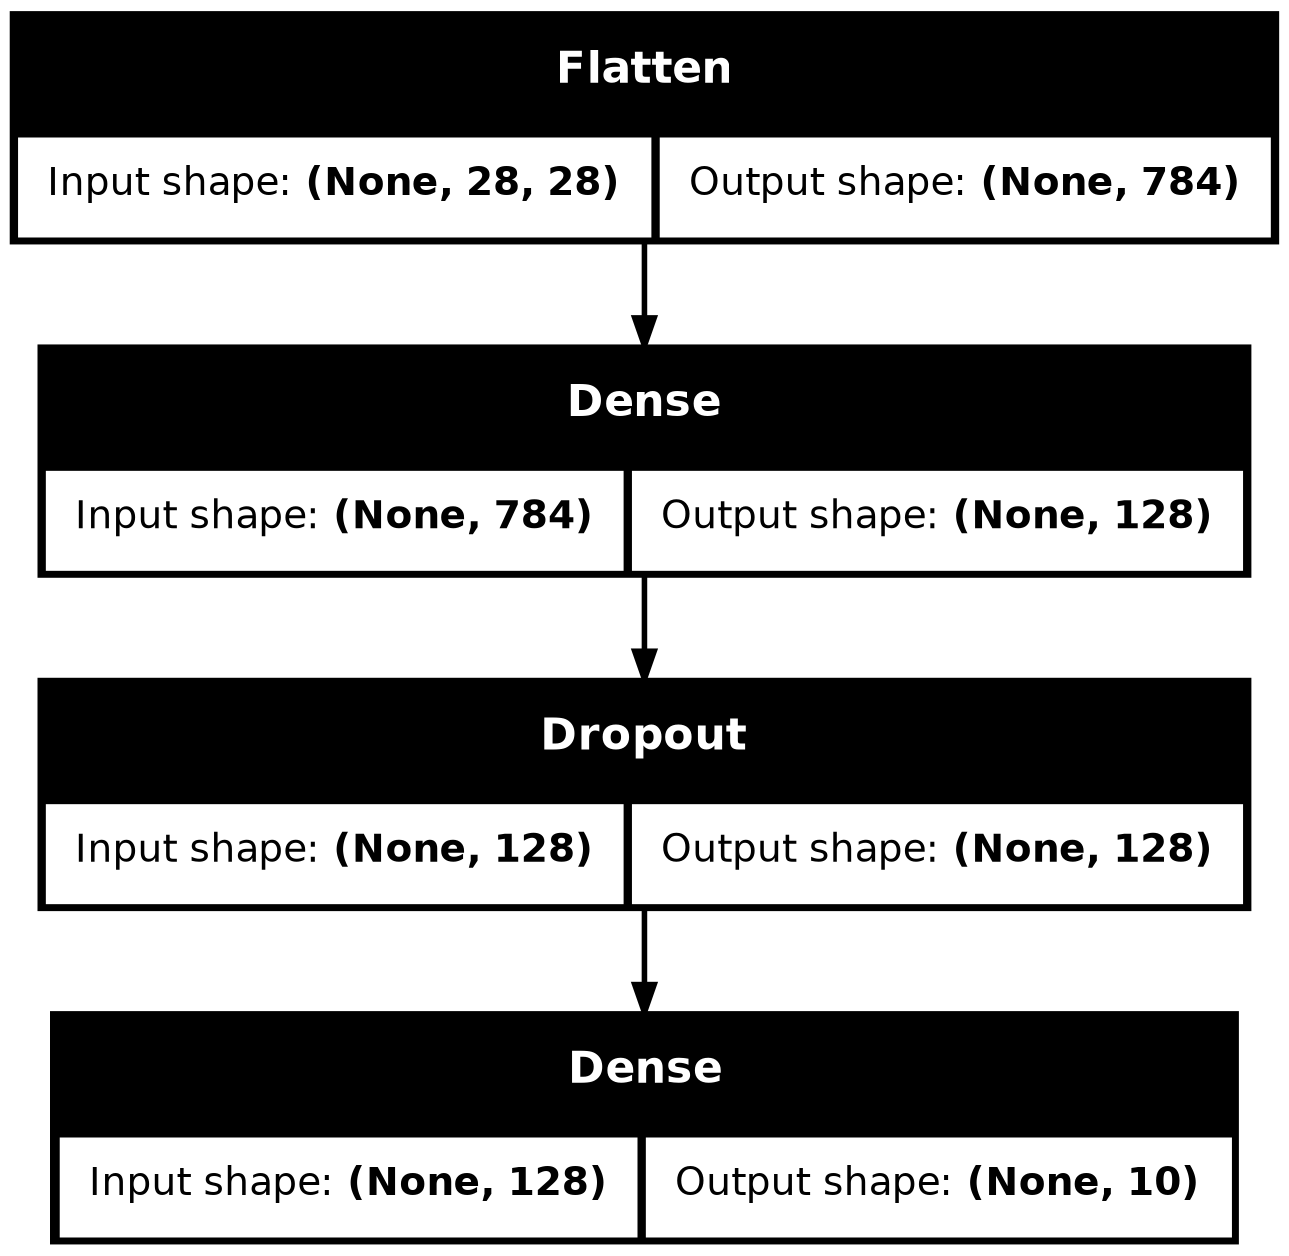

In [21]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [17]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9761 - loss: 0.0813


[0.08128485083580017, 0.9761000275611877]

# 3 hidden layers

In [22]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)), # this goes ahead and :flattens the grid into 784 numbers

  # This is your first hidden layer n 128 neurons
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),# 20% of your data is left out to lower the chance pof overfittinhs

  # # This is your first hidden layer n 64 neurons
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dropout(0.2),# 20% of your data is left out to lower the chance pof overfittinh

  # # This is your first hidden layer n 32 neurons
  tf.keras.layers.Dense(32, activation='relu'),
  tf.keras.layers.Dropout(0.2),# 20% of your data is left out to lower the chance pof overfittinh
  
  tf.keras.layers.Dense(10, activation='softmax')
])

In [24]:
model.compile(
    optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)

model.evaluate(x_test, y_test)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.8698 - loss: 0.4316
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9425 - loss: 0.2077
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9538 - loss: 0.1641
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9614 - loss: 0.1391
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9664 - loss: 0.1193
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9758 - loss: 0.0874


[0.08741005510091782, 0.9757999777793884]

In [25]:
model.compile(
    optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10)

model.evaluate(x_test, y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.9683 - loss: 0.1122
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9714 - loss: 0.0998
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9732 - loss: 0.0942
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9752 - loss: 0.0863
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9765 - loss: 0.0805
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9771 - loss: 0.0783
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9777 - loss: 0.0753
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9807 - loss: 0.0685
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9806 - loss: 0.0663
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9812 - loss: 0.0643
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9790 - loss: 0.0795


[0.07953565567731857, 0.9789999723434448]

In [ ]:
(x_train, y_train),(x_test, y_test) = mnist.load_data()
# x_train, x_test = x_train / 255.0, x_test / 255.0  # they allow inseatd of the pizels to transition from 0 -255 but to 0-1 this helps in convergence

In [27]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)), # this goes ahead and :flattens the grid into 784 numbers

  # This is your first hidden layer n 128 neurons
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),# 20% of your data is left out to lower the chance pof overfittinhs

  # # This is your first hidden layer n 64 neurons
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dropout(0.2),# 20% of your data is left out to lower the chance pof overfittinh

#   # # This is your first hidden layer n 32 neurons
  tf.keras.layers.Dense(32, activation='relu'),
  tf.keras.layers.Dropout(0.2),# 20% of your data is left out to lower the chance pof overfittinh
  
  tf.keras.layers.Dense(10, activation='softmax')
])

In [28]:
model.compile(
    optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10)

model.evaluate(x_test, y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.4158 - loss: 2.8305
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7889 - loss: 0.7813
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8566 - loss: 0.5438
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8874 - loss: 0.4355
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9015 - loss: 0.3798
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9150 - loss: 0.3346
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9202 - loss: 0.3065
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9246 - loss: 0.2910
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9277 - loss: 0.2738
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9331 - loss: 0.2601
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9533 - loss: 0.1928


[0.19276346266269684, 0.9532999992370605]

In [30]:
(x_train, y_train),(x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  # they allow inseatd of the pizels to transition from 0 -255 but to 0-1 this helps in convergence

In [31]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)), # this goes ahead and :flattens the grid into 784 numbers

  # This is your first hidden layer n 128 neurons
  tf.keras.layers.Dense(128, activation='relu'), 

  # # This is your first hidden layer n 64 neurons
  tf.keras.layers.Dense(64, activation='relu'), 

#   # # This is your first hidden layer n 32 neurons
  tf.keras.layers.Dense(32, activation='relu'), 
  
  tf.keras.layers.Dense(10, activation='softmax')
])

In [32]:
model.compile(
    optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10)

model.evaluate(x_test, y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9251 - loss: 0.2550
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9679 - loss: 0.1056
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9755 - loss: 0.0772
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9812 - loss: 0.0591
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9854 - loss: 0.0468
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9873 - loss: 0.0397
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9884 - loss: 0.0342
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9908 - loss: 0.0282
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9914 - loss: 0.0263
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9918 - loss: 0.0230
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9780 - loss: 0.0932


[0.09323696047067642, 0.9779999852180481]

In [37]:
(x_train, y_train),(x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  # they allow inseatd of the pizels to transition from 0 -255 but to 0-1 this helps in convergence

In [38]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)), # this goes ahead and :flattens the grid into 784 numbers

  # This is your first hidden layer n 128 neurons
  tf.keras.layers.Dense(256, activation='relu'), 
 tf.keras.layers.Dropout(0.2),
  # # This is your first hidden layer n 64 neurons
  tf.keras.layers.Dense(128, activation='relu'), 
 tf.keras.layers.Dropout(0.2),
  
  tf.keras.layers.Dense(10, activation='softmax')
  
])

In [39]:
model.compile(
    optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

model.fit(x_train, y_train, epochs=3)

model.evaluate(x_test, y_test)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9212 - loss: 0.2590
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9626 - loss: 0.1232
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9715 - loss: 0.0933
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9716 - loss: 0.0838


[0.08383943140506744, 0.9715999960899353]

In [36]:
model.compile(
    optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10)

model.evaluate(x_test, y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.9214 - loss: 0.2598
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9628 - loss: 0.1224
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9714 - loss: 0.0927
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9763 - loss: 0.0760
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9796 - loss: 0.0673
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9805 - loss: 0.0595
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9835 - loss: 0.0511
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9854 - loss: 0.0471
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9854 - loss: 0.0443
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9870 - loss: 0.0396
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9799 - loss: 0.0758


[0.07581570744514465, 0.9799000024795532]